In [127]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report

import optuna
import optuna.visualization as vis
import time

import scipy.stats as st

from sklearn.datasets import  fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, make_scorer, mean_absolute_percentage_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_ind, randint

import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
import joblib
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor

In [128]:
df3 = pd.read_csv(r'..\data\clean\df_clean.csv')

In [130]:
df3.head()

,property_type,neighborhood,city,price,sq_m_built,n_bedrooms,bathrooms,floor,year_built,exterior,...,needs_renovating,parking,swimming_pool,garden,air_conditioning,heating,price_cheap_city,price_cheap_neigh,price_cheap_property,log_price
0,Flat / apartment,El Raval,Barcelona,530000.0,80,2,1,3,1912.0,1,...,0,0,0,0,1,1,3.086356,3.060900,2.030635,13.180632
1,Flat / apartment,El Raval,Barcelona,165000.0,58,2,1,3,1850.0,1,...,0,0,0,0,0,0,3.086356,3.060900,2.030635,12.013701
2,Flat / apartment,Ciutat Vella,Barcelona,430000.0,155,3,2,1,2003.0,1,...,0,0,0,0,1,1,3.086356,5.078603,2.030635,12.971540
3,Flat / apartment,El Raval,Barcelona,279999.0,89,2,2,3,1920.0,1,...,0,0,0,0,1,1,3.086356,3.060900,2.030635,12.542541
4,Flat / apartment,El Raval,Barcelona,230000.0,70,2,2,1,1900.0,1,...,0,0,0,0,1,0,3.086356,3.060900,2.030635,12.345835


# Train Test Split

## Creating featurings and target 

In [131]:
features = df3.drop(columns = ['price','second_hand','heating','needs_renovating','log_price'])
target = df3["log_price"]

In [132]:
X_train, X_test, y_train, y_test = train_test_split(features,target, test_size = 0.20, random_state=0)

> Checking for inconsistency on the columns

In [133]:
print("X_train shape:", X_train.shape)
print("X_train columns:", X_train.columns)
print("X_test shape:", X_test.shape)
print("X_test columns:", X_test.columns)

X_train shape: (7968, 19)
X_train columns: Index(['property_type', 'neighborhood', 'city', 'sq_m_built', 'n_bedrooms',
       'bathrooms', 'floor', 'year_built', 'exterior', 'lift', 'terrace',
       'balcony', 'parking', 'swimming_pool', 'garden', 'air_conditioning',
       'price_cheap_city', 'price_cheap_neigh', 'price_cheap_property'],
      dtype='object')
X_test shape: (1993, 19)
X_test columns: Index(['property_type', 'neighborhood', 'city', 'sq_m_built', 'n_bedrooms',
       'bathrooms', 'floor', 'year_built', 'exterior', 'lift', 'terrace',
       'balcony', 'parking', 'swimming_pool', 'garden', 'air_conditioning',
       'price_cheap_city', 'price_cheap_neigh', 'price_cheap_property'],
      dtype='object')


## Preparing the data for the Pipeline

In [134]:
numerical_col = ['sq_m_built','n_bedrooms','bathrooms','floor','year_built']

In [135]:
categorical_col = ['property_type','neighborhood','city']

In [136]:
bool_col_1 = ['exterior', 'lift', 'terrace', 'balcony', 'second_hand',
                  'needs_renovating', 'parking', 'swimming_pool', 'garden',
                  'air_conditioning', 'heating']

> Checking the featurings that have less importance

In [137]:
df3[bool_col_1].mean().sort_values()

swimming_pool       0.021584
garden              0.021584
parking             0.115751
needs_renovating    0.130107
terrace             0.358097
balcony             0.410903
air_conditioning    0.451862
lift                0.644815
exterior            0.749222
heating             0.862564
second_hand         0.953720
dtype: float64

In [138]:
bool_col = ['exterior', 'lift', 'terrace', 'balcony', 'parking', 'swimming_pool', 'garden', 
                  'air_conditioning']

In [139]:
num_col_2 = ['price_cheap_city', 'price_cheap_neigh', 'price_cheap_property']

>  Creating a pipeline to transform numerical col with power transf. and categorical with onehotenconding.

In [140]:
num_pipeline = Pipeline([('power', PowerTransformer())])

In [141]:
cat_pipeline = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))])

In [142]:
bool_pipeline = 'passthrough'

> Creating the preprocessor pipeline

In [143]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline,numerical_col),
    ('cat',cat_pipeline,categorical_col),
    ('bool',bool_pipeline,bool_col),
    ('num_2','passthrough',num_col_2)], remainder='drop')

# Models

## Bagging Regressor

In [116]:
model_bagging = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor', BaggingRegressor(random_state=0))])

In [117]:
model_bagging.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning']),
                                                 ('num_2', 'passthrough',
                                                  ['price_cheap_city',
                                                   'price_cheap_neigh',
                                                   'price_cheap_property',
                                                   'rooms_per_m'])])),
                ('regressor', BaggingRegressor(random_state=0))])

In [118]:
y_pred_log = model_bagging.predict(X_test)

> Using function to back to real prices 

In [119]:
y_pred_bagging = np.exp(y_pred_log)
y_true_bagging = np.exp(y_test)

In [120]:
print(f"MAE: {mean_absolute_error(y_true_bagging, y_pred_bagging):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_bagging, y_pred_bagging)):,.2f} €")
mape = mean_absolute_percentage_error(y_true_bagging, y_pred_bagging)
print("MAPE: {:.2f}%".format(mape*100))
print(f"R2: {r2_score(y_true_bagging, y_pred_bagging):.2f}")

MAE: 89,279.63 €
RMSE: 174,527.60 €
MAPE: 19.21%
R2: 0.84


## Gradient Boosting

In [33]:
model_gradient = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=0))])

In [34]:
model_gradient.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning'])])),
                ('regressor', GradientBoostingRegressor(random_state=0))])

In [35]:
y_pred_log_gra = model_gradient.predict(X_test)

In [36]:
y_pred_gra = np.exp(y_pred_log_gra)
y_true_gra = np.exp(y_test)

In [37]:
print(f"MAE: {mean_absolute_error(y_true_gra, y_pred_gra):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_gra, y_pred_gra)):,.2f} €")
mape = mean_absolute_percentage_error(y_true_gra, y_pred_gra)
print("MAPE: {:.2f}%".format(mape*100))
print(f"R2: {r2_score(y_true_gra, y_pred_gra):.2f}")

MAE: 110,592.42 €
RMSE: 197,135.32 €
MAPE: 24.33%
R2: 0.80


## Random Forest

In [39]:
model_rforest = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor',RandomForestRegressor(n_estimators=100, max_depth=20, random_state=0))])

In [40]:
model_rforest.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, random_state=0))])

In [41]:
y_pred_log_rforest = model_rforest.predict(X_test)

In [42]:
y_pred_rforest = np.exp(y_pred_log_rforest)
y_true_rforest = np.exp(y_test)

In [43]:
print(f"MAE: {mean_absolute_error(y_true_rforest, y_pred_rforest):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_rforest, y_pred_rforest)):,.2f} €")
print(f"R2: {r2_score(y_true_rforest, y_pred_rforest):.2f}")
mape = mean_absolute_percentage_error(y_true_rforest, y_pred_rforest)
print("MAPE: {:.2f}%".format(mape*100))

MAE: 93,388.24 €
RMSE: 177,716.99 €
R2: 0.84
MAPE: 20.65%


## Adaboost 

In [144]:
model_adaboost = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor', AdaBoostRegressor(DecisionTreeRegressor(max_depth=20),
                            n_estimators=100,learning_rate=0.1,random_state=0))])

In [145]:
model_adaboost.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning']),
                                                 ('num_2', 'passthrough',
                                                  ['price_cheap_city',
                                                   'price_cheap_neigh',
                                                   'price_cheap_property'])])),
                ('regressor',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=20),
                                   learning_rate=0.1, n_estimators=100,
                                   random_state=0))])

In [146]:
y_pred_log_adaboost = model_adaboost.predict(X_test)

In [147]:
y_pred_adaboost = np.exp(y_pred_log_adaboost)
y_true_adaboost = np.exp(y_test)

In [148]:
print(f"MAE: {mean_absolute_error(y_true_adaboost, y_pred_adaboost):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_adaboost, y_pred_adaboost)):,.2f} €")
print(f"R2: {r2_score(y_true_adaboost, y_pred_adaboost):.2f}")
mape = mean_absolute_percentage_error(y_true_adaboost, y_pred_adaboost)
print("MAPE: {:.2f}%".format(mape*100))

MAE: 78,762.66 €
RMSE: 166,788.58 €
R2: 0.86
MAPE: 17.25%


> Saving model

In [149]:
joblib.dump(model_adaboost, r"..\models\model_ada.pkl")

['..\\models\\model_ada.pkl']

## Trying hyperparemeters models 

## Grid Search 

In [70]:
model_adaboost_gs = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=0),
        random_state=0))])

In [ ]:
parameter_grid = {
    'regressor__n_estimators': [100],
    'regressor__learning_rate': [0.1, 0.3],
    'regressor__estimator__max_depth': [5, 10]}

confidence_level = 0.95 
folds = 10


gs = GridSearchCV(model_adaboost_gs, param_grid=parameter_grid, cv=folds, verbose=10)

start_time = time.time()
gs.fit(X_train, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {gs.best_params_}")
print(f"The R2 is: {gs.best_score_: .4f}")

results_gs_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)

gs_mean_score = results_gs_df.iloc[0,-3]
gs_sem = results_gs_df.iloc[0,-2] / np.sqrt(folds)

gs_tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
gs_lower_bound = gs_mean_score - ( gs_tc * gs_sem )
gs_upper_bound = gs_mean_score + ( gs_tc * gs_sem )

print(f"The R2 confidence interval for the best combination of hyperparameters is: ({gs_lower_bound: .4f}, {gs_mean_score: .4f}, {gs_upper_bound: .4f})")

best_model_gs = gs.best_estimator_

y_pred_train_df = best_model_gs.predict(X_train)
y_pred_test_df  = np.exp(best_model_gs.predict(X_test))
y_true_test = np.exp(y_test)

print("\n")
print(f"Test MAE: {mean_absolute_error(y_pred_test_df,y_true_test): .4f}")
print(f"Test MSE: {mean_squared_error(y_true_test, y_pred_test_df): .4f}")
print(f"Test RMSE: {root_mean_squared_error(y_true_test, y_pred_test_df): .2f}")
print(f"Test R2 score:  {r2_score(y_test, best_model_gs.predict(X_test)):.4f}")
print(f"R²: {r2_score(y_true_test, y_pred_test_df):.4f}")
mape_test = mean_absolute_percentage_error(y_true_test, y_pred_test_df)
print(f"Test MAPE: {mape_test*100:.2f}%")
print("\n")

## Hist Gradient Boosting 

In [69]:
model_hgb = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', HistGradientBoostingRegressor())
])

In [ ]:
parameter_grid = {
    'regressor__max_iter': [100],
    'regressor__max_depth': [5, 10]}

confidence_level = 0.95 
folds = 10


gs = GridSearchCV(model_hgb, param_grid=parameter_grid, cv=folds, verbose=10)

start_time = time.time()
gs.fit(X_train, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {gs.best_params_}")
print(f"The R2 is: {gs.best_score_: .4f}")

results_hgb_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)

hgb_mean_score = results_hgb_df.iloc[0,-3]
hgb_sem = results_hgb_df.iloc[0,-2] / np.sqrt(folds)

hgb_tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
hgb_lower_bound = hgb_mean_score - ( hgb_tc * hgb_sem )
hgb_upper_bound = hgb_mean_score + ( hgb_tc * hgb_sem )

print(f"The R2 confidence interval for the best combination of hyperparameters is: ({hgb_lower_bound: .4f}, {hgb_mean_score: .4f}, {hgb_upper_bound: .4f})")

best_model_hgb = gs.best_estimator_

y_pred_train_df = best_model_hgb.predict(X_train)
y_pred_test_df  = np.exp(best_model_hgb.predict(X_test))
y_true_test = np.exp(y_test)

print("\n")
print(f"Test MAE: {mean_absolute_error(y_pred_test_df,y_true_test): .4f}")
print(f"Test MSE: {mean_squared_error(y_true_test, y_pred_test_df): .4f}")
print(f"Test RMSE: {root_mean_squared_error(y_true_test, y_pred_test_df): .2f}")
print(f"Test R2 score:  {r2_score(y_test, best_model_hgb.predict(X_test)):.4f}")
print(f"R²: {r2_score(y_true_test, y_pred_test_df):.4f}")
mape_test = mean_absolute_percentage_error(y_true_test, y_pred_test_df)
print(f"Test MAPE: {mape_test*100:.2f}%")
print("\n")

## Random Forest 

In [ ]:
model_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [ ]:
param_dist = {
    'regressor__n_estimators': randint(100, 300),
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}
folds = 10
confidence_level = 0.95
search = RandomizedSearchCV(
    model_rf,
    param_distributions=param_dist
    n_iter=20,  
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
start_time = time.time()
search.fit(X_train, y_train_log)
end_time = time.time()

print(f"\nTime taken to find the best combination of hyperparameters: {end_time - start_time:.2f} seconds")
print(f"Best hyperparâmetros: {search.best_params_}")
print(f"The R²: {search.best_score_:.4f}")

results_df = pd.DataFrame(search.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0, -3]
sem = results_df.iloc[0, -2] / np.sqrt(folds)
t_crit = st.t.ppf(1 - (1 - confidence_level) / 2, df=folds - 1)
ci_lower = mean_score - (t_crit * sem)
ci_upper = mean_score + (t_crit * sem)
print(f"The R2 confidence interval for the best combination of hyperparameters is: ({ci_lower:.4f}, {mean_score:.4f}, {ci_upper:.4f})")

best_rf_model = search.best_estimator_
y_pred_log = best_rf_model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

print(f"MAE: {mean_absolute_error(y_true, y_pred):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):,.2f} €")
print(f"R2: {r2_score(y_true, y_pred):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_true, y_pred)*100:.2f}%")

## LGBMRegrassor

In [114]:
model_lgb = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=1000, learning_rate=0.05))
])

model_lgb.fit(X_train, y_train)
y_pred_log = model_lgb.predict(X_test)
y_pred_lgb = np.exp(y_pred_log)
y_true_lgb = np.exp(y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1114
[LightGBM] [Info] Number of data points in the train set: 7968, number of used features: 112
[LightGBM] [Info] Start training from score 12.732529


In [115]:
print(f"MAE: {mean_absolute_error(y_true_lgb, y_pred_lgb):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_lgb, y_pred_lgb)):,.2f} €")
print(f"R2: {r2_score(y_true_lgb, y_pred_lgb):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_true_lgb, y_pred_lgb)*100:.2f}%")

MAE: 84,150.86 €
RMSE: 161,293.75 €
R2: 0.86
MAPE: 18.25%


In [83]:
joblib.dump(model_lgb, r"..\models\model_lgb.pkl")

['..\\models\\model_lgb.pkl']

# After analysis all results, the model Adaboost have the best results. 

# Analazing model Adaboost 

## Scatter plot of estimate value and real 

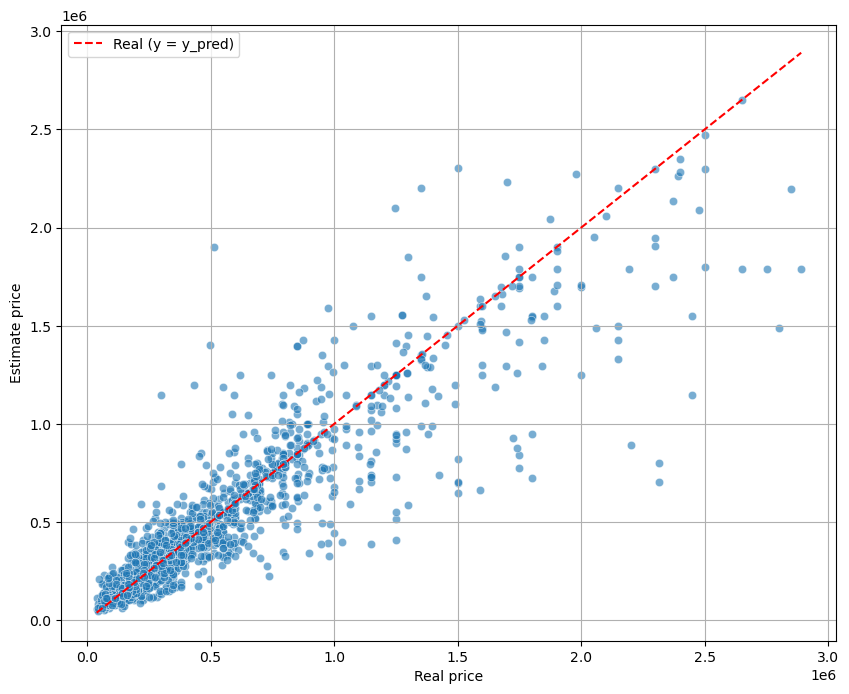

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_true_adaboost, y=y_pred_adaboost, alpha=0.6)
plt.plot([y_true_adaboost.min(), y_true_adaboost.max()],
         [y_true_adaboost.min(), y_true_adaboost.max()],
         '--', color='red', label='Real (y = y_pred)')
plt.xlabel('Real price')
plt.ylabel('Estimate price')
plt.legend()
plt.grid(True)
plt.show()

> Plot per city 

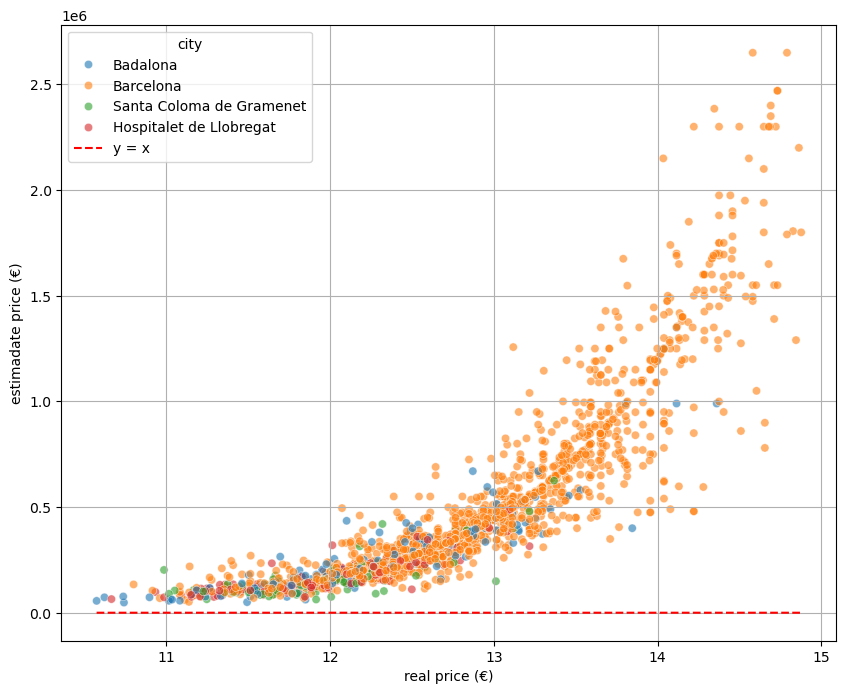

In [163]:
df_results = pd.DataFrame({
    'Real_price': y_test,                    
    'Pred_price': y_pred_adaboost,          
    'city': X_test['city'].values           
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_results,
    x='Real_price',
    y='Pred_price',
    hue='city',
    alpha=0.6
)

# Linha de referência y = x
plt.plot(
    [df_results['Real_price'].min(), df_results['Real_price'].max()],
    [df_results['Real_price'].min(), df_results['Real_price'].max()],
    '--', color='red', label='y = x'
)

plt.xlabel('real price (€)')
plt.ylabel('estimadate price (€)')
plt.legend(title='city')
plt.grid(True)
plt.show()

## Scatter plot of residuos 

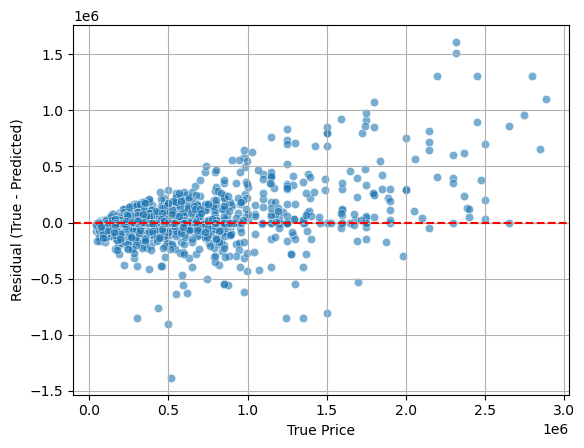

In [74]:
residuals = y_true_adaboost - y_pred_adaboost
sns.scatterplot(x=y_true_adaboost, y=residuals, alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('True Price')
plt.ylabel('Residual (True - Predicted)')
plt.grid(True)
plt.show()

# Learning Curve

In [157]:
from sklearn.model_selection import learning_curve
model = AdaBoostRegressor(random_state=0)

In [158]:
X = features
y = target

In [160]:
train_size_abs, train_scores, test_scores = learning_curve(
    model_adaboost, X, y, train_sizes=[0.3, 0.6, 0.9],cv=5,scoring='r2',n_jobs=-1
)


for train_size, cv_train_scores, cv_test_scores in zip(
    train_size_abs, train_scores, test_scores
):
    print(f"{train_size} samples were used to train the model")
    print(f"The average train accuracy is {cv_train_scores.mean():.2f}")
    print(f"The average test accuracy is {cv_test_scores.mean():.2f}")

2390 samples were used to train the model
The average train accuracy is 1.00
The average test accuracy is 0.87
4780 samples were used to train the model
The average train accuracy is 1.00
The average test accuracy is 0.89
7171 samples were used to train the model
The average train accuracy is 1.00
The average test accuracy is 0.90


# Creating bins for price

In [170]:
model_adaboost.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning']),
                                                 ('num_2', 'passthrough',
                                                  ['price_cheap_city',
                                                   'price_cheap_neigh',
                                                   'price_cheap_property'])])),
                ('regressor',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=20),
                                   learning_rate=0.1, n_estimators=100,
                                   random_state=0))])

In [171]:
y_pred_test = model_adaboost.predict(X_test)


In [172]:
y_pred_test_price = np.exp(y_pred_test)
y_test_price = np.exp(y_test)

In [173]:
df_results = X_test.copy()
df_results['price'] = y_test_price
df_results['pred_price'] = y_pred_test_price

In [189]:
bins = [0, 80000, 300000, 1000000, df_results['price'].max()]
labels = ['0-80k', '81k-300k', '301k-1.0M', '1.5M+']
df_results['price_bin'] = pd.cut(df_results['price'], bins=bins, labels=labels, include_lowest=True)

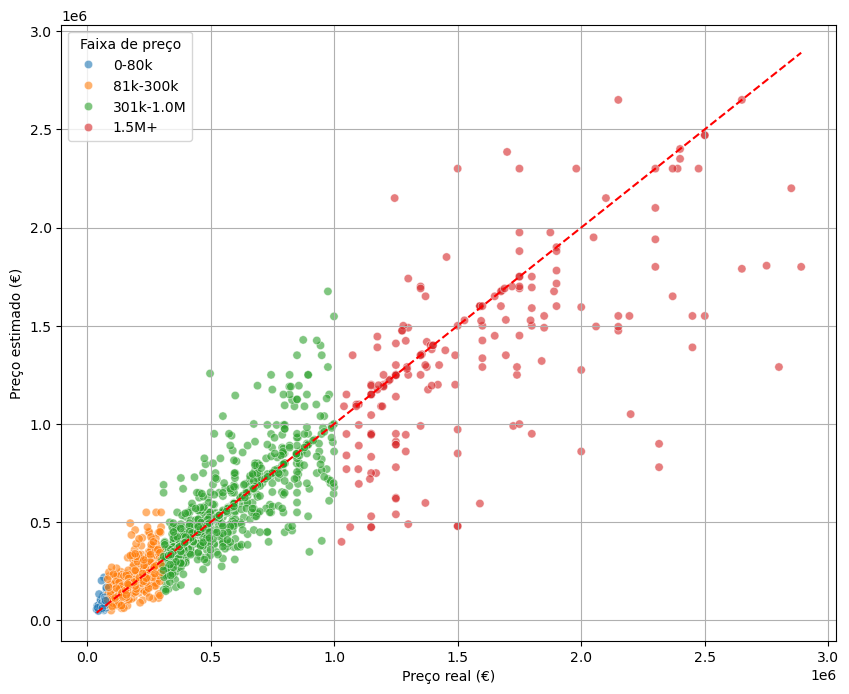

In [190]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_results,
    x='price',
    y='pred_price',
    hue='price_bin',
    alpha=0.6
)

plt.plot(
    [df_results['price'].min(), df_results['price'].max()],
    [df_results['price'].min(), df_results['price'].max()],
    '--', color='red'
)

plt.xlabel('Preço real (€)')
plt.ylabel('Preço estimado (€)')
plt.legend(title='Faixa de preço')
plt.grid(True)
plt.show()


In [191]:
print(df_results['price_bin'].value_counts())

price_bin
301k-1.0M    911
81k-300k     843
1.5M+        187
0-80k         52
Name: count, dtype: int64


# Creating a copy of teh DF with only properties below 1.5M

In [192]:
df_filtered = df3[df3['price'] <= 1_000_000].copy()

In [193]:
df_filtered

,property_type,neighborhood,city,price,sq_m_built,n_bedrooms,bathrooms,floor,year_built,exterior,...,parking,swimming_pool,garden,air_conditioning,heating,price_cheap_city,price_cheap_neigh,price_cheap_property,log_price,price_bin
0,Flat / apartment,El Raval,Barcelona,530000.0,80,2,1,3,1912.000000,1,...,0,0,0,1,1,3.086356,3.060900,2.030635,13.180632,301k-1.5M
1,Flat / apartment,El Raval,Barcelona,165000.0,58,2,1,3,1850.000000,1,...,0,0,0,0,0,3.086356,3.060900,2.030635,12.013701,81k-300k
2,Flat / apartment,Ciutat Vella,Barcelona,430000.0,155,3,2,1,2003.000000,1,...,0,0,0,1,1,3.086356,5.078603,2.030635,12.971540,301k-1.5M
3,Flat / apartment,El Raval,Barcelona,279999.0,89,2,2,3,1920.000000,1,...,0,0,0,1,1,3.086356,3.060900,2.030635,12.542541,81k-300k
4,Flat / apartment,El Raval,Barcelona,230000.0,70,2,2,1,1900.000000,1,...,0,0,0,1,0,3.086356,3.060900,2.030635,12.345835,81k-300k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9956,Flat / apartment,Nou Barris,Barcelona,150000.0,45,2,1,1,1953.000000,1,...,0,0,0,0,1,3.086356,1.827805,2.030635,11.918391,81k-300k
9957,Flat / apartment,El Camp de l'Arpa del Clot,Barcelona,249633.0,63,2,1,2,2008.000000,1,...,0,0,0,1,1,3.086356,3.304043,2.030635,12.427747,81k-300k
9958,Flat / apartment,El Camp de l'Arpa del Clot,Barcelona,218900.0,46,2,1,2,1900.000000,0,...,0,0,0,0,0,3.086356,3.304043,2.030635,12.296370,81k-300k
9959,Flat / apartment,El Camp de l'Arpa del Clot,Barcelona,245000.0,67,1,1,5,1959.641026,0,...,0,0,0,1,1,3.086356,3.304043,2.030635,12.409013,81k-300k


## Creating new training with the new DF

In [194]:
features_fil = df_filtered.drop(columns = ['price','second_hand','heating','needs_renovating','log_price'])
target_fil = df_filtered["log_price"]

In [195]:
X_train, X_test, y_train, y_test = train_test_split(features_fil,target_fil, test_size = 0.20, random_state=0)

## Model with the new DF

In [196]:
model_adaboost = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor', AdaBoostRegressor(DecisionTreeRegressor(max_depth=20),
                            n_estimators=100,learning_rate=0.1,random_state=0))])

In [197]:
model_adaboost.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning']),
                                                 ('num_2', 'passthrough',
                                                  ['price_cheap_city',
                                                   'price_cheap_neigh',
                                                   'price_cheap_property'])])),
                ('regressor',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=20),
                                   learning_rate=0.1, n_estimators=100,
                                   random_state=0))])

In [198]:
y_pred_log_adaboost = model_adaboost.predict(X_test)

In [199]:
y_pred_adaboost = np.exp(y_pred_log_adaboost)
y_true_adaboost = np.exp(y_test)

In [200]:
print(f"MAE: {mean_absolute_error(y_true_adaboost, y_pred_adaboost):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_adaboost, y_pred_adaboost)):,.2f} €")
print(f"R2: {r2_score(y_true_adaboost, y_pred_adaboost):.2f}")
mape = mean_absolute_percentage_error(y_true_adaboost, y_pred_adaboost)
print("MAPE: {:.2f}%".format(mape*100))

MAE: 48,810.63 €
RMSE: 85,617.43 €
R2: 0.85
MAPE: 15.67%


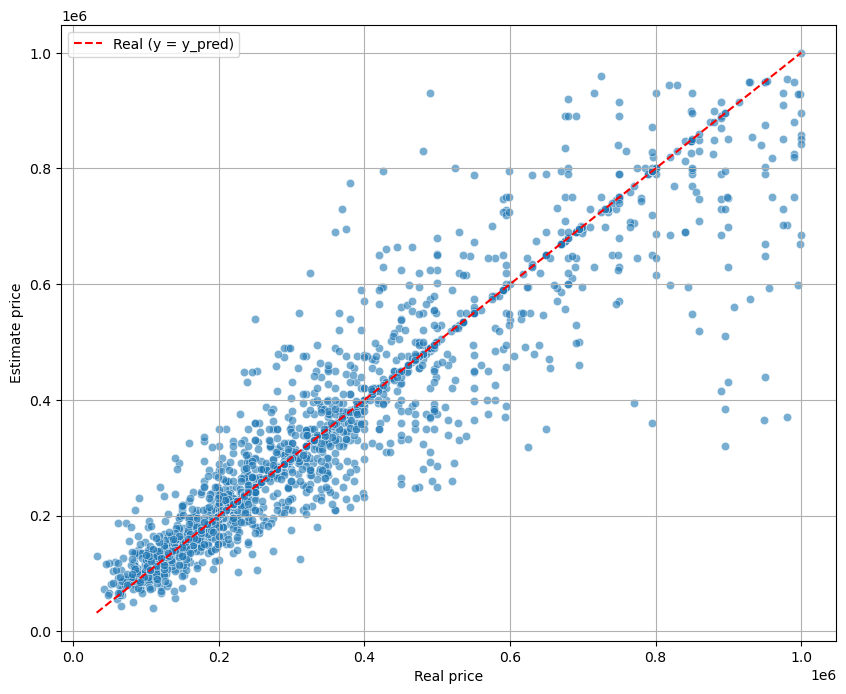

In [215]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_true_adaboost, y=y_pred_adaboost, alpha=0.6)
plt.plot([y_true_adaboost.min(), y_true_adaboost.max()],
         [y_true_adaboost.min(), y_true_adaboost.max()],
         '--', color='red', label='Real (y = y_pred)')
plt.xlabel('Real price')
plt.ylabel('Estimate price')
plt.legend()
plt.grid(True)
plt.savefig(r"..\figures\real_vs_estim.png")
plt.show()

In [203]:
joblib.dump(model_adaboost, r"..\models\model_ada_1M.pkl")

['..\\models\\model_ada_1M.pkl']

In [206]:
df_filtered.to_csv(r'..\data\clean\df_1M.csv', index=False)

In [209]:
df_corr = df_filtered.drop(columns = ['price_cheap_city','price_cheap_neigh','price_cheap_property','log_price'])

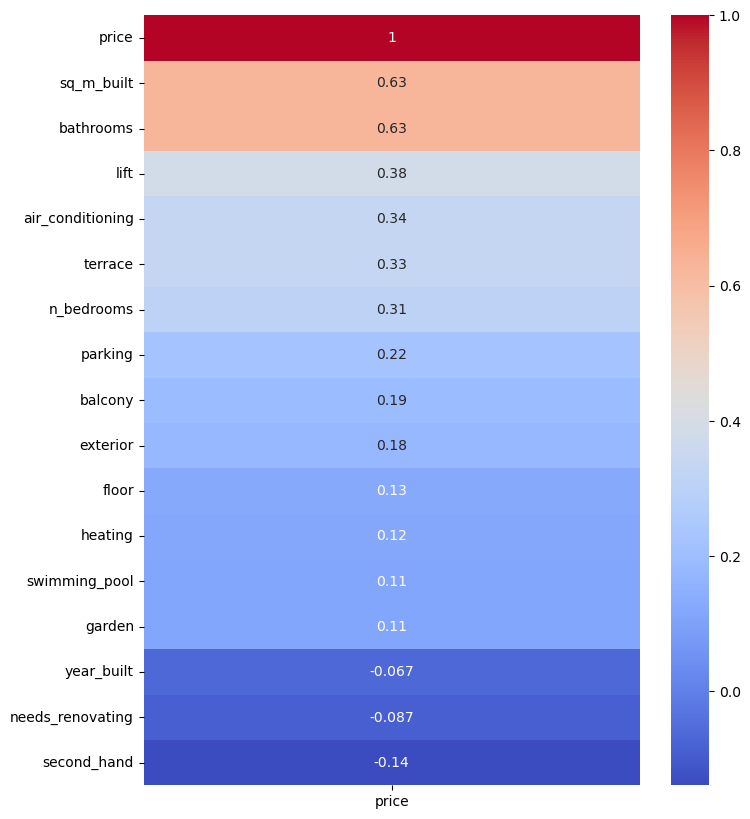

In [213]:
corr = df_corr.corr(numeric_only=True)
corr_target = corr['price'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap='coolwarm')
plt.savefig(r"..\figures\corr_price.png")
plt.show()